In [1]:
%load_ext autotime

import scarf

scarf.__version__

'1.0.0'

time: 1.48 s (started: 2026-07-17 01:20:40 +02:00)


In [2]:
scarf.fetch_dataset(dataset_name="tenx_10K_pbmc-v1_atacseq", save_path="scarf_datasets")

time: 22.7 s (started: 2026-07-17 01:20:41 +02:00)


In [3]:
reader = scarf.CrH5Reader("scarf_datasets/tenx_10K_pbmc-v1_atacseq/data.h5")
reader.assayFeats

,ATAC
type,Peaks
start,0
end,89796
nFeatures,89796


time: 54.2 ms (started: 2026-07-17 01:21:02 +02:00)


In [4]:
writer = scarf.CrToZarr(
    reader,
    zarr_loc="scarf_datasets/tenx_10K_pbmc-v1_atacseq/data.zarr",
    chunk_size=(1000, 2000),
)
writer.dump(batch_size=1000)

Writing countsT shape=(89796, 8728) chunks=(89796, 5978)



time: 3min 7s (started: 2026-07-17 01:21:02 +02:00)


In [5]:
ds = scarf.DataStore("scarf_datasets/tenx_10K_pbmc-v1_atacseq/data.zarr", nthreads=4)

time: 24.2 s (started: 2026-07-17 01:24:00 +02:00)


247 cells flagged for filtering out using attribute ATAC_nCounts



294 cells flagged for filtering out using attribute ATAC_nFeatures



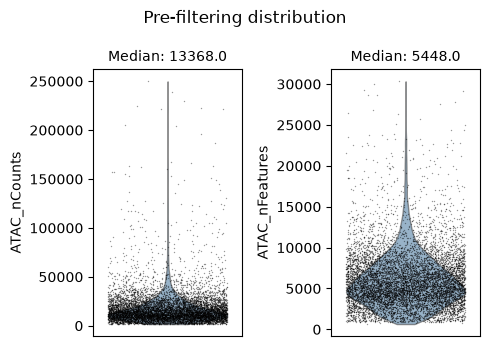

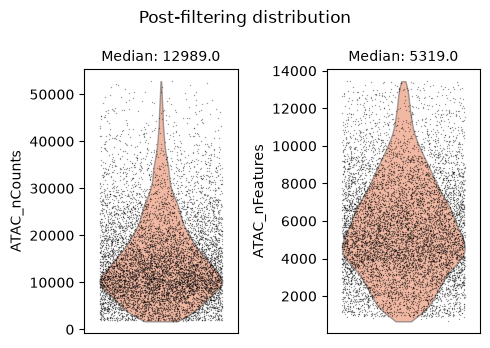

time: 1.65 s (started: 2026-07-17 01:24:22 +02:00)


In [6]:
ds.auto_filter_cells()

In [7]:
ds.mark_prevalent_peaks(top_n=25000)

time: 1min 12s (started: 2026-07-17 01:24:24 +02:00)


In [8]:
ds.ATAC.feats.head()

,I,ids,names,dropOuts,nCells,I__prevalent_peaks,stats_I_prevalence
0,True,chr1:565107-565550,chr1:565107-565550,8645,83,False,0.206181
1,True,chr1:569174-569639,chr1:569174-569639,8529,199,False,0.350725
2,True,chr1:713460-714823,chr1:713460-714823,6242,2486,True,1.993573
3,True,chr1:752422-753038,chr1:752422-753038,8296,432,True,0.680701
4,True,chr1:762106-763359,chr1:762106-763359,6850,1878,True,1.570790


time: 977 ms (started: 2026-07-17 01:25:33 +02:00)


In [9]:
ds.make_graph(
    feat_key="prevalent_peaks",
    k=21,
    dims=50,
    n_centroids=100,
    lsi_skip_first=True,
)

make_graph step 1/7: normalize expression matrix (computing)



make_graph step 1/7: normalize expression matrix finished in 20.4s (computing)



make_graph step 2/7: normalization statistics (computing)



make_graph step 2/7: normalization statistics finished in 0.0s (computing)



make_graph step 3/7: dimension reduction, ANN index, and kmeans (computing)



...

ANN recall: 99.36%



make_graph step 7/7: finalize graph metadata (computing)



make_graph step 7/7: finalize graph metadata finished in 0.0s (computing)



make_graph finished in 53.8s (7/7 steps, 53.6s in logged steps)



time: 53.9 s (started: 2026-07-17 01:25:34 +02:00)


In [10]:
ds.run_umap(n_epochs=500, min_dist=0.1, spread=1, parallel=True)

Training UMAP:   0%|                                                                                          …

time: 8.86 s (started: 2026-07-17 01:26:24 +02:00)


/home/parashar/scarf/scarf/metadata.py:416: RuntimeWarning: overflow encountered in cast
  a = np.empty(self.N).astype(values.dtype)


In [11]:
ds.run_leiden_clustering(resolution=0.6)

time: 1.41 s (started: 2026-07-17 01:26:33 +02:00)


In [12]:
ds.cells.head()

,I,ids,names,ATAC_UMAP2,ATAC_nFeatures,ATAC_nCounts,ATAC_UMAP1,ATAC_leiden_cluster
0,True,AAACGAAAGAGCGAAA-1,AAACGAAAGAGCGAAA-1,-6.689109,5546.0,13187.0,-7.084217,1
1,True,AAACGAAAGAGTTTGA-1,AAACGAAAGAGTTTGA-1,-9.980007,6586.0,16074.0,-8.057801,4
2,True,AAACGAAAGCGAGCTA-1,AAACGAAAGCGAGCTA-1,0.848246,9214.0,28009.0,7.224609,7
3,False,AAACGAAAGGCTTCGC-1,AAACGAAAGGCTTCGC-1,NaN,30325.0,221747.0,NaN,-1
4,True,AAACGAAAGTGCTGAG-1,AAACGAAAGTGCTGAG-1,-6.127776,4922.0,11440.0,-6.587667,1


time: 120 ms (started: 2026-07-17 01:26:35 +02:00)


/home/parashar/scarf/scarf/plots.py:849: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  axs.flat[0].figure.show()


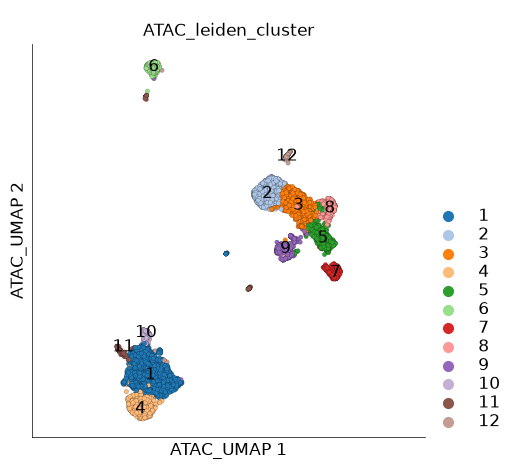

time: 508 ms (started: 2026-07-17 01:26:35 +02:00)


In [13]:
ds.plot_layout(layout_key="ATAC_UMAP", color_by="ATAC_leiden_cluster")

In [14]:
scarf.fetch_dataset(dataset_name="annotations", save_path="scarf_datasets")

time: 10.1 s (started: 2026-07-17 01:26:35 +02:00)


In [15]:
ds.add_melded_assay(
    from_assay="ATAC",
    external_bed_fn="scarf_datasets/annotations/human_GRCh37_gencode_v38_gene_body.bed.gz",
    peaks_col="ids",
    renormalization=False,
    assay_label="GeneScores",
    assay_type="RNA",
)

Chromosome chrM not in the input peak coordinates



33935/62446 features did not overlap with any peak



Writing countsT shape=(62446, 8728) chunks=(61511, 2182)



Minimum cell count (6.539499236477921) is lower than size factor multiplier (1000)



time: 2min 20s (started: 2026-07-17 01:26:45 +02:00)


In [16]:
ds

DataStore has 8426 (8728) cells with 2 assays: GeneScores ATAC
   Cell metadata:
            'I', 'ids', 'names', 'ATAC_nFeatures', 'GeneScores_percentRibo', 
            'GeneScores_percentMito', 'GeneScores_nCounts', 'GeneScores_nFeatures', 'ATAC_nCounts', 'ATAC_UMAP2', 
            'ATAC_leiden_cluster', 'ATAC_UMAP1'
   ATAC assay has 86049 (89796) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'dropOuts', 
            'I__prevalent_peaks'
   GeneScores assay has 28357 (62446) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'dropOuts', 
          

time: 89.5 ms (started: 2026-07-17 01:28:57 +02:00)


/home/parashar/scarf/scarf/plots.py:849: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  axs.flat[0].figure.show()


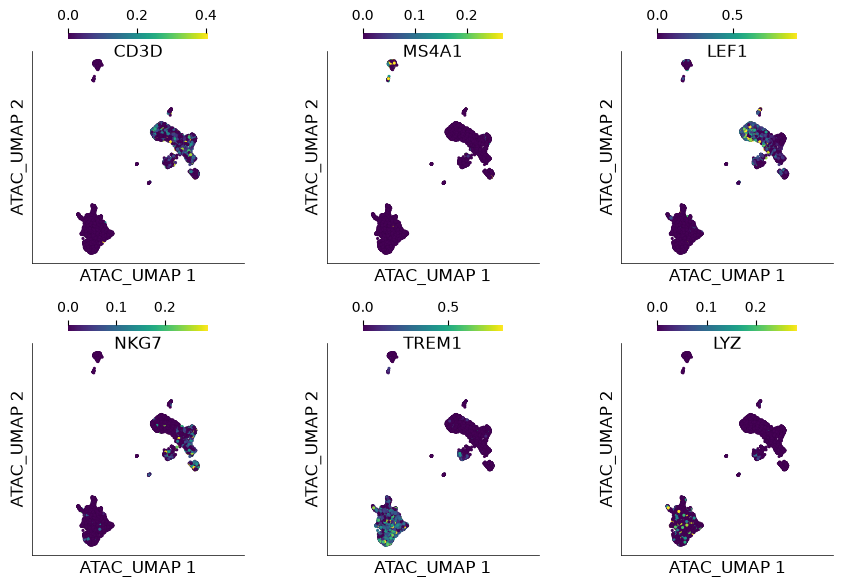

time: 56.5 s (started: 2026-07-17 01:28:57 +02:00)


In [17]:
ds.plot_layout(
    layout_key="ATAC_UMAP",
    from_assay="GeneScores",
    color_by=["CD3D", "MS4A1", "LEF1", "NKG7", "TREM1", "LYZ"],
    clip_fraction=0.01,
    n_columns=3,
    width=3,
    height=3,
    point_size=5,
    scatter_kwargs={"lw": 0.01},
)